In [198]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

In [199]:
# =========================
# LOAD DATA
# =========================

train = pd.read_csv(r"C:\Users\chari\Desktop\Future_Interns\FUTURE_ML_01\data\raw\train.csv")
stores = pd.read_csv(r"C:\Users\chari\Desktop\Future_Interns\FUTURE_ML_01\data\raw\stores.csv")
oil = pd.read_csv(r"C:\Users\chari\Desktop\Future_Interns\FUTURE_ML_01\data\raw\oil.csv")
transactions = pd.read_csv(r"C:\Users\chari\Desktop\Future_Interns\FUTURE_ML_01\data\raw\transactions.csv")
holidays = pd.read_csv(r"C:\Users\chari\Desktop\Future_Interns\FUTURE_ML_01\data\raw\holidays_events.csv")

train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

In [200]:
# =========================
# MERGE DATASETS
# =========================

df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(transactions, on=['store_nbr','date'], how='left')

In [201]:
# =========================
# OIL FEATURE ENGINEERING
# =========================

oil = oil.set_index('date')
oil = oil.reindex(pd.date_range(oil.index.min(), oil.index.max()))
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()
oil = oil.reset_index().rename(columns={'index':'date'})

df = df.merge(oil, on='date', how='left')
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()

In [202]:
# =========================
# HOLIDAY FEATURE
# =========================

holidays = holidays[holidays['transferred'] == False]
holidays['is_holiday'] = 1

holidays = holidays.groupby('date')['is_holiday'].max().reset_index()

df = df.merge(holidays, on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0)

In [203]:
# =========================
# DATE FEATURES
# =========================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear

In [204]:
# =========================
# LAG FEATURES
# =========================

df = df.sort_values(['store_nbr','family','date'])

df['lag_1'] = df.groupby(['store_nbr','family'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store_nbr','family'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store_nbr','family'])['sales'].shift(14)

In [205]:
# =========================
# ROLLING FEATURES
# =========================

df['rolling_mean_7'] = df.groupby(['store_nbr','family'])['sales'].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df.groupby(['store_nbr','family'])['sales'].shift(1).rolling(14).mean()
df['rolling_median_7'] = df.groupby(['store_nbr','family'])['sales'].shift(1).rolling(7).median()

In [206]:
# =========================
# ADVANCED FEATURES
# =========================

df['momentum_7'] = df['lag_1'] - df['lag_7']

df['promo_last_7'] = df.groupby(['store_nbr','family'])['onpromotion'].shift(1).rolling(7).sum()

df['promo_x_transactions'] = df['onpromotion'] * df['transactions']

df['rolling_std_14'] = df.groupby(['store_nbr','family'])['sales'].shift(1).rolling(14).std()

df['dow_avg'] = df.groupby(['store_nbr','family','dayofweek'])['sales'].transform('mean')

In [207]:
# =========================
# CLEAN DATA
# =========================

df = df.dropna()

In [208]:
# =========================
# TRAIN TEST SPLIT
# =========================

train_df = df[df['date'] < '2017-01-01']
test_df  = df[df['date'] >= '2017-01-01']

train_df = train_df.drop(columns=['date'])
test_df  = test_df.drop(columns=['date'])

In [209]:
# =========================
# SPLIT FEATURES
# =========================

X_train = train_df.drop('sales', axis=1)
y_train = train_df['sales']

X_test = test_df.drop('sales', axis=1)
y_test = test_df['sales']

In [210]:
# =========================
# ENCODING
# =========================

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [224]:
# =========================
# MODEL TRAINING
# =========================

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [225]:
# =========================
# MODEL EVALUATION
# =========================

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 238.5921158610661
MAE: 61.364280932026276


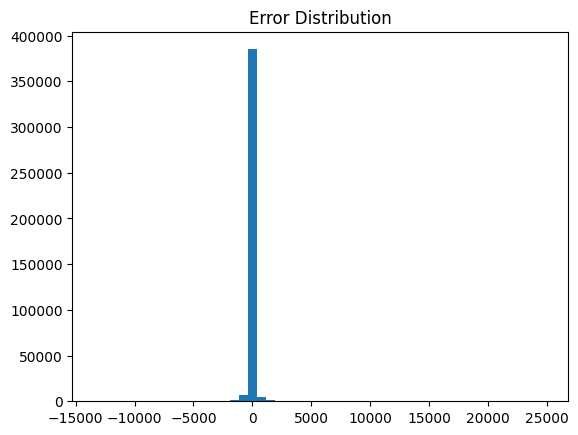

In [213]:
# =========================
# ERROR DISTRIBUTION
# =========================

plt.hist(y_test - preds, bins=50)
plt.title("Error Distribution")
plt.show()

In [214]:
# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

rolling_mean_7      0.477836
lag_7               0.251230
lag_14              0.058351
lag_1               0.057036
rolling_median_7    0.038437
transactions        0.007522
rolling_mean_14     0.006069
dow_avg             0.005667
city_Playas         0.005329
dayofweek           0.004705
dtype: float32


In [226]:
# =========================
# SAVE MODEL
# =========================

os.makedirs("outputs", exist_ok=True)

with open("outputs/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!


In [227]:
# =========================
# SAVE FEATURE COLUMNS
# =========================

with open("outputs/feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)